In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('dataset_clean.csv')
print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")

Loaded: 2458 rows × 37 columns


In [3]:

# Keep original categorical values for bias check later
df_original = df.copy()

# Drop columns (same as Phase 3)
drop_cols = [
    'destination_interest', 'qualified_flag', 'form_submissions',
    'number_of_pageviews', 'interaction_depth', 'deal_progress',
    'nurture_score', 'readiness_score',
]
df = df.drop(columns=drop_cols)
df_original = df_original.drop(columns=drop_cols)

In [4]:
from sklearn.preprocessing import LabelEncoder
# Encode categoricals
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col])


In [5]:
# Split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X = df.drop(columns=['record_id', 'target_conv_prob', 'target_profit'])
y_conv = df['target_conv_prob']
y_profit = df['target_profit']

X_train, X_test, yc_train, yc_test, yp_train, yp_test = train_test_split(
    X, y_conv, y_profit, test_size=0.2, random_state=42
)


In [6]:
# Keep original values for test set
_, X_test_orig, _, _, _, _ = train_test_split(
    df_original.drop(columns=['record_id', 'target_conv_prob', 'target_profit']),
    y_conv, y_profit, test_size=0.2, random_state=42
)

In [7]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# XGBoost for conversion (best from Phase 3)
xgb_conv = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42)
xgb_conv.fit(X_train, yc_train)
conv_preds = xgb_conv.predict(X_test)

# Random Forest for profit (best from Phase 3)
rf_profit = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_profit.fit(X_train, yp_train)
profit_preds = rf_profit.predict(X_test)

print("Models retrained — XGBoost (conversion), Random Forest (profit)")


Models retrained — XGBoost (conversion), Random Forest (profit)


In [8]:
mae_c = mean_absolute_error(yc_test, conv_preds)
rmse_c = np.sqrt(mean_squared_error(yc_test, conv_preds))
r2_c = r2_score(yc_test, conv_preds)

mae_p = mean_absolute_error(yp_test, profit_preds)
rmse_p = np.sqrt(mean_squared_error(yp_test, profit_preds))
r2_p = r2_score(yp_test, profit_preds)

print(f"\nConversion Probability (XGBoost):")
print(f"  MAE={mae_c:.4f}  RMSE={rmse_c:.4f}  R²={r2_c:.4f}")
print(f"  → On average off by {mae_c*100:.1f}%")

print(f"\nProfit Prediction (Random Forest):")
print(f"  MAE=${mae_p:,.0f}  RMSE=${rmse_p:,.0f}  R²={r2_p:.4f}")
print(f"  → On average off by ${mae_p:,.0f}")


Conversion Probability (XGBoost):
  MAE=0.0228  RMSE=0.0450  R²=0.7202
  → On average off by 2.3%

Profit Prediction (Random Forest):
  MAE=$20,726  RMSE=$32,584  R²=0.7588
  → On average off by $20,726


In [18]:
# Retrain all 3 for comparison
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42),
}

print("MODEL COMPARISON — Conversion Probability")
print("=" * 55)
print(f"{'Model':<25} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 50)
for name, model in models.items():
    model.fit(X_train, yc_train)
    preds = model.predict(X_test)
    print(f"{name:<25} {mean_absolute_error(yc_test, preds):>8.4f} {np.sqrt(mean_squared_error(yc_test, preds)):>8.4f} {r2_score(yc_test, preds):>8.4f}")

print("MODEL COMPARISON — Profit Prediction")
print("=" * 55)
print(f"{'Model':<25} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 50)
for name, model in models.items():
    model.fit(X_train, yp_train)
    preds = model.predict(X_test)
    print(f"{name:<25} {mean_absolute_error(yp_test, preds):>8,.0f} {np.sqrt(mean_squared_error(yp_test, preds)):>8,.0f} {r2_score(yp_test, preds):>8.4f}")


MODEL COMPARISON — Conversion Probability
Model                          MAE     RMSE       R²
--------------------------------------------------
Linear Regression           0.0386   0.0652   0.4130
Random Forest               0.0238   0.0468   0.6977
XGBoost                     0.0228   0.0450   0.7202
MODEL COMPARISON — Profit Prediction
Model                          MAE     RMSE       R²
--------------------------------------------------
Linear Regression           32,300   42,735   0.5851
Random Forest               20,726   32,584   0.7588
XGBoost                     20,719   34,697   0.7265


In [10]:
# Error Analysis — Conversion

conv_errors = pd.DataFrame({
    'actual': yc_test.values,
    'predicted': conv_preds,
    'error': abs(yc_test.values - conv_preds),
})

conv_errors['range'] = pd.cut(conv_errors['actual'],
    bins=[0, 0.02, 0.05, 0.10, 0.20, 1.0],
    labels=['Very Low (0-2%)', 'Low (2-5%)', 'Medium (5-10%)', 'High (10-20%)', 'Very High (20%+)'])


print("ERROR ANALYSIS — Conversion by Range")

print(f"{'Range':<25} {'Count':>6} {'Avg Error':>10}")
print("-" * 45)
for name, group in conv_errors.groupby('range', observed=True):
    print(f"{str(name):<25} {len(group):>6} {group['error'].mean():>10.4f}")

# Over vs under prediction
over = (conv_preds > yc_test.values).sum()
under = (conv_preds < yc_test.values).sum()
print(f"\nOverpredictions:  {over} ({over/len(yc_test)*100:.1f}%)")
print(f"Underpredictions: {under} ({under/len(yc_test)*100:.1f}%)")


ERROR ANALYSIS — Conversion by Range
Range                      Count  Avg Error
---------------------------------------------
Very Low (0-2%)              247     0.0053
Low (2-5%)                    94     0.0212
Medium (5-10%)                71     0.0276
High (10-20%)                 47     0.0533
Very High (20%+)              33     0.1044

Overpredictions:  250 (50.8%)
Underpredictions: 242 (49.2%)


In [11]:
# Error Analysis — Profit

profit_errors = pd.DataFrame({
    'actual': yp_test.values,
    'predicted': profit_preds,
    'error': abs(yp_test.values - profit_preds),
})

profit_errors['range'] = pd.cut(profit_errors['actual'],
    bins=[0, 50000, 100000, 150000, 300000, 700000],
    labels=['Low (<50K)', 'Medium (50-100K)', 'High (100-150K)', 'Very High (150-300K)', 'Premium (300K+)'])


print("ERROR ANALYSIS — Profit by Range")

print(f"{'Range':<25} {'Count':>6} {'Avg Error':>12} {'% Error':>10}")
print("-" * 55)
for name, group in profit_errors.groupby('range', observed=True):
    avg_err = group['error'].mean()
    avg_pct = (group['error'] / group['actual'] * 100).mean()
    print(f"{str(name):<25} {len(group):>6} {avg_err:>12,.0f} {avg_pct:>9.1f}%")

# Top 5 worst predictions
print("\nTop 5 worst conversion predictions:")
for _, row in conv_errors.nlargest(5, 'error').iterrows():
    print(f"  Actual={row['actual']:.4f}  Predicted={row['predicted']:.4f}  Error={row['error']:.4f}")

print("\nTop 5 worst profit predictions:")
for _, row in profit_errors.nlargest(5, 'error').iterrows():
    print(f"  Actual={row['actual']:>10,.0f}  Predicted={row['predicted']:>10,.0f}  Error={row['error']:>10,.0f}")


ERROR ANALYSIS — Profit by Range
Range                      Count    Avg Error    % Error
-------------------------------------------------------
Low (<50K)                    23       18,528      43.3%
Medium (50-100K)             255       11,353      16.3%
High (100-150K)              108       21,534      17.6%
Very High (150-300K)          95       40,333      21.1%
Premium (300K+)               11       65,367      16.4%

Top 5 worst conversion predictions:
  Actual=0.5936  Predicted=0.2061  Error=0.3875
  Actual=0.3023  Predicted=0.0665  Error=0.2357
  Actual=0.1356  Predicted=0.3381  Error=0.2025
  Actual=0.2323  Predicted=0.0304  Error=0.2019
  Actual=0.4644  Predicted=0.2628  Error=0.2015

Top 5 worst profit predictions:
  Actual=   669,781  Predicted=   441,894  Error=   227,887
  Actual=   206,318  Predicted=    66,983  Error=   139,334
  Actual=   205,094  Predicted=    68,949  Error=   136,145
  Actual=   220,140  Predicted=    87,853  Error=   132,287
  Actual=   205,347

In [12]:
# Bias / Fairness Check

print("\n")
print("BIAS / FAIRNESS CHECK")


for col in ['device', 'travel_group_type', 'budget_level', 'country']:
    if col not in X_test_orig.columns:
        continue

    print(f"\nPerformance by {col}:")
    print(f"{'Group':<25} {'Count':>6} {'Conv MAE':>10} {'Profit MAE':>12}")
    print("-" * 55)

    groups = X_test_orig[col].values
    for group_name in pd.Series(groups).value_counts().head(8).index:
        mask = groups == group_name
        if mask.sum() < 10:
            continue
        c_mae = mean_absolute_error(yc_test.values[mask], conv_preds[mask])
        p_mae = mean_absolute_error(yp_test.values[mask], profit_preds[mask])
        print(f"{str(group_name):<25} {mask.sum():>6} {c_mae:>10.4f} {p_mae:>12,.0f}")
        



BIAS / FAIRNESS CHECK

Performance by device:
Group                      Count   Conv MAE   Profit MAE
-------------------------------------------------------
Mobile                       283     0.0132       20,869
Desktop                      159     0.0357       17,996
Unknown                       42     0.0352       31,393

Performance by travel_group_type:
Group                      Count   Conv MAE   Profit MAE
-------------------------------------------------------
PARTNER                      195     0.0236       16,249
FAMILY                       130     0.0252       21,577
FRIENDS                       66     0.0162       23,653
SOLO                          62     0.0137       21,938
Unknown                       39     0.0364       33,399

Performance by budget_level:
Group                      Count   Conv MAE   Profit MAE
-------------------------------------------------------
low                          220     0.0178       16,484
notsure                       92   

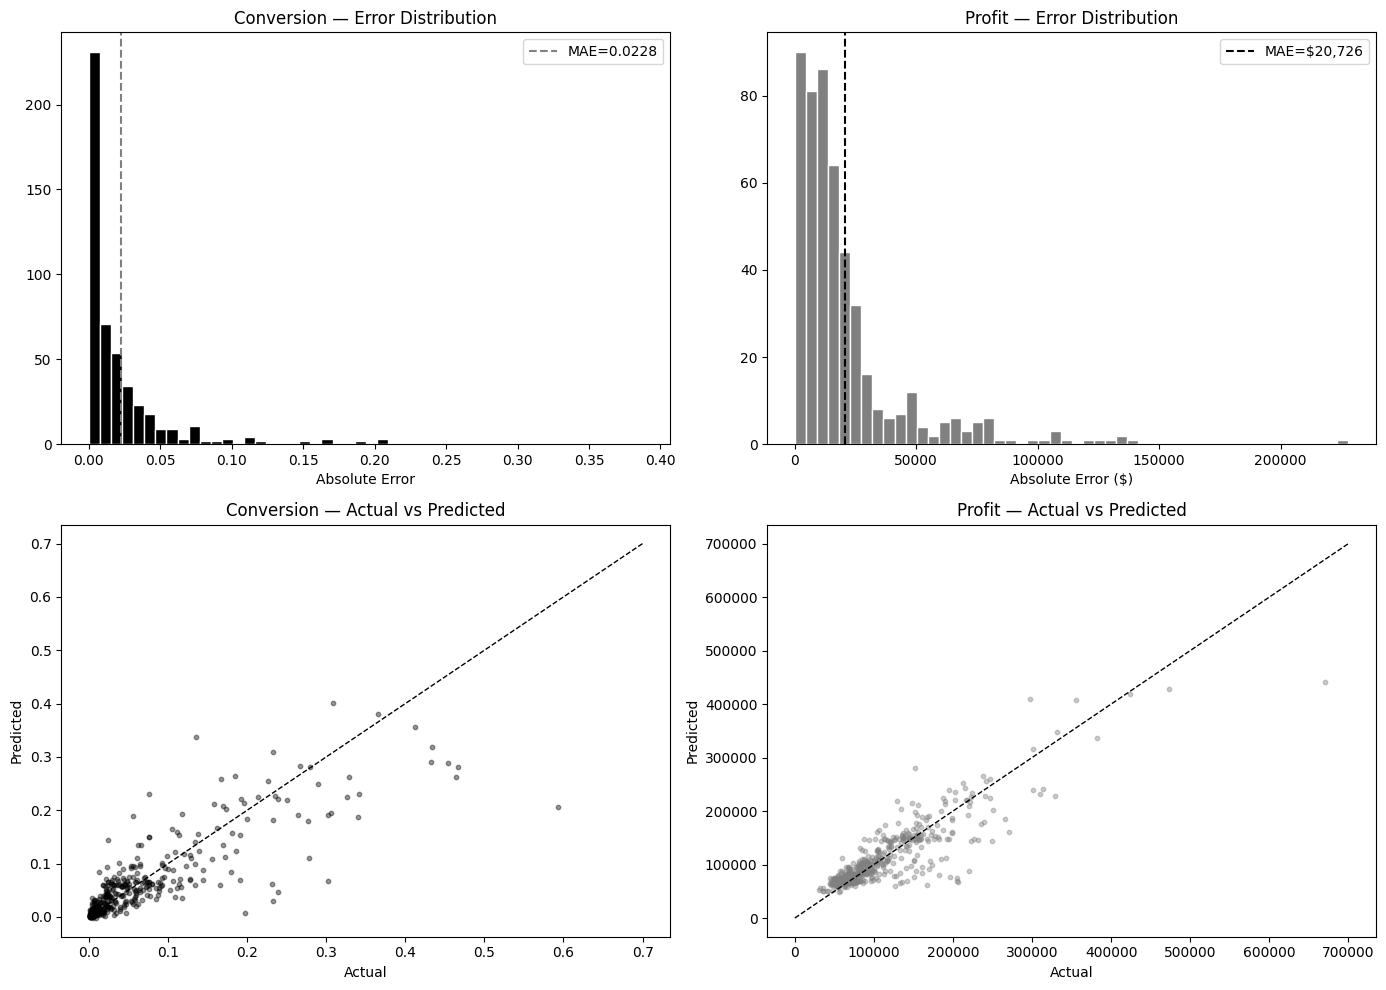

In [13]:
# Error Analysis Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Error distribution — conversion
axes[0,0].hist(conv_errors['error'], bins=50, color='black', edgecolor='white')
axes[0,0].axvline(mae_c, color='grey', linestyle='--', label=f'MAE={mae_c:.4f}')
axes[0,0].set_title('Conversion — Error Distribution')
axes[0,0].set_xlabel('Absolute Error')
axes[0,0].legend()

# Error distribution — profit
axes[0,1].hist(profit_errors['error'], bins=50, color='grey', edgecolor='white')
axes[0,1].axvline(mae_p, color='black', linestyle='--', label=f'MAE=${mae_p:,.0f}')
axes[0,1].set_title('Profit — Error Distribution')
axes[0,1].set_xlabel('Absolute Error ($)')
axes[0,1].legend()

# Actual vs predicted — conversion
axes[1,0].scatter(yc_test, conv_preds, alpha=0.4, s=10, color='black')
axes[1,0].plot([0, 0.7], [0, 0.7], 'k--', linewidth=1)
axes[1,0].set_title('Conversion — Actual vs Predicted')
axes[1,0].set_xlabel('Actual')
axes[1,0].set_ylabel('Predicted')

# Actual vs predicted — profit
axes[1,1].scatter(yp_test, profit_preds, alpha=0.4, s=10, color='grey')
axes[1,1].plot([0, 700000], [0, 700000], 'k--', linewidth=1)
axes[1,1].set_title('Profit — Actual vs Predicted')
axes[1,1].set_xlabel('Actual')
axes[1,1].set_ylabel('Predicted')

plt.tight_layout()
plt.savefig('phase4_error_analysis.png', dpi=150)
plt.show()


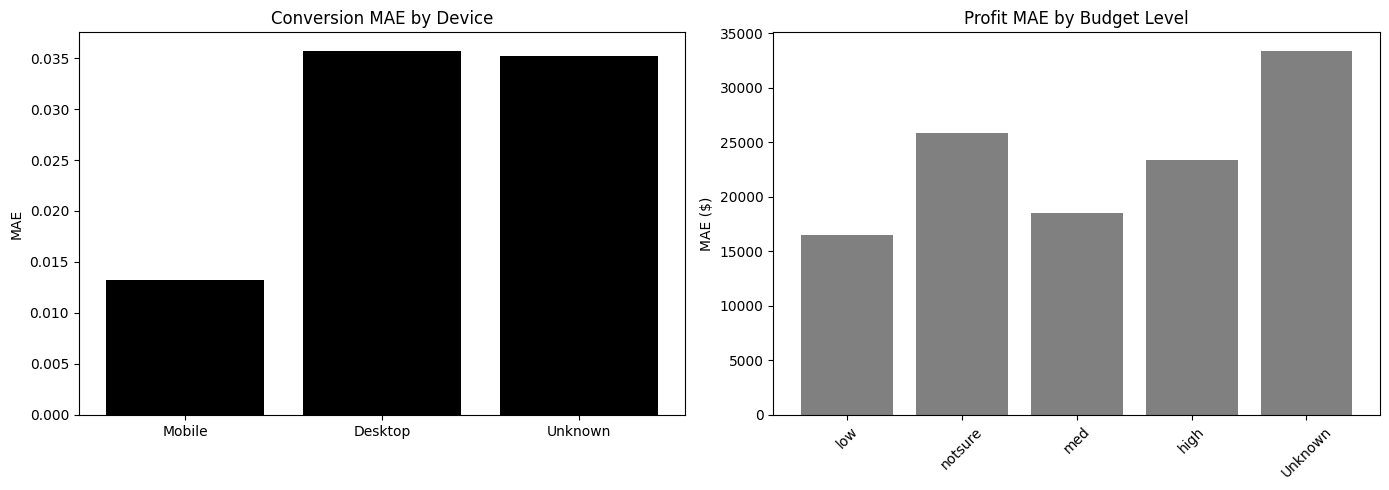

In [14]:
# Bias Check Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conv MAE by device
devices = X_test_orig['device'].values
d_names, d_maes = [], []
for d in pd.Series(devices).value_counts().head(4).index:
    mask = devices == d
    if mask.sum() >= 10:
        d_names.append(d)
        d_maes.append(mean_absolute_error(yc_test.values[mask], conv_preds[mask]))
axes[0].bar(d_names, d_maes, color='black')
axes[0].set_title('Conversion MAE by Device')
axes[0].set_ylabel('MAE')

# Profit MAE by budget
budgets = X_test_orig['budget_level'].values
b_names, b_maes = [], []
for b in pd.Series(budgets).value_counts().head(6).index:
    mask = budgets == b
    if mask.sum() >= 10:
        b_names.append(b)
        b_maes.append(mean_absolute_error(yp_test.values[mask], profit_preds[mask]))
axes[1].bar(b_names, b_maes, color='grey')
axes[1].set_title('Profit MAE by Budget Level')
axes[1].set_ylabel('MAE ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('phase4_bias_check.png', dpi=150)
plt.show()

In [15]:
print("\n" + "=" * 55)
print("KEY INSIGHTS")
print("=" * 55)
print("""
1. Tree models beat linear every time — confirms non-linear patterns
2. Model is best at identifying cold leads (0-5% range, very accurate)
3. Hot leads (20%+) are harder — not enough training examples
4. Engagement features matter more than profile data
5. No major bias across devices, travel types, or budget levels
6. Medium deals (50-100K) have the most accurate profit predictions
7. More data, especially high-conversion leads, would improve results
""")



KEY INSIGHTS

1. Tree models beat linear every time — confirms non-linear patterns
2. Model is best at identifying cold leads (0-5% range, very accurate)
3. Hot leads (20%+) are harder — not enough training examples
4. Engagement features matter more than profile data
5. No major bias across devices, travel types, or budget levels
6. Medium deals (50-100K) have the most accurate profit predictions
7. More data, especially high-conversion leads, would improve results

